# LLM-DCP Implementation

In [29]:
from transformers import AutoTokenizer, AutoModelForCausalLM
from transformers import LlamaConfig, LlamaForCausalLM, LlamaTokenizer
import torch
import torch.nn as nn
import torch.nn.functional as F
from typing import List, Dict
import torch.optim as optim
import matplotlib.pyplot as plt
import copy
from collections import deque
import random

In [30]:
device = torch.device("cpu")

model_name = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
tokenizer = LlamaTokenizer.from_pretrained(model_name)
model = LlamaForCausalLM.from_pretrained(model_name, torch_dtype="auto", device_map="auto")
model.eval()

Some parameters are on the meta device because they were offloaded to the disk and cpu.


LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(32000, 2048)
    (layers): ModuleList(
      (0-21): 22 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=256, bias=False)
          (v_proj): Linear(in_features=2048, out_features=256, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=2048, out_features=5632, bias=False)
          (up_proj): Linear(in_features=2048, out_features=5632, bias=False)
          (down_proj): Linear(in_features=5632, out_features=2048, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((2048,), eps=1e-05)
    (rotary_emb): 

# Define DCP Agent & Critic

In [31]:
class DCPAgent(nn.Module):
    def __init__(self, hidden_size: int, dropout=0.1):
        super().__init__()
        self.policy_net = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 1),
        )

    def forward(self, hidden_states: torch.Tensor) -> torch.Tensor:
        logits = self.policy_net(hidden_states).squeeze(-1)
        keep_probs = torch.sigmoid(logits)
        return keep_probs


In [32]:
class Critic(nn.Module):
    def __init__(self, hidden_size):
        super(Critic, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Linear(hidden_size // 2, 1)
        )

    def forward(self, hidden_states):
        pooled = hidden_states.mean(dim=1)
        values = self.fc(pooled).squeeze(-1) 
        return values

In [33]:
class ReplayBuffer:
    def __init__(self, max_size):
        self.buffer = deque(maxlen=max_size)

    def add(self, trajectory):
        self.buffer.append(trajectory)

    def sample(self, batch_size):
        return random.sample(self.buffer, batch_size)

    def __len__(self):
        return len(self.buffer)

    def clear(self):
        self.buffer.clear()


# Create critic & initialize lists for logging

In [34]:
critic = Critic(hidden_size=model.config.hidden_size)
critic_optimizer = torch.optim.Adam(critic.parameters(), lr=1e-4)

all_total_losses = []
all_policy_losses = []
all_critic_losses = []
all_total_rewards = []
all_compression_rates = []

# Define functions

In [35]:
def encode_prompt_query(prompt: str, query: str):
    prompt_ids = tokenizer(prompt, return_tensors="pt").input_ids
    query_ids = tokenizer(query, return_tensors="pt").input_ids
    full_input_ids = torch.cat([prompt_ids, query_ids[:, 1:]], dim=1)  # Remove <BOS> from query
    return full_input_ids.view(1, -1), prompt_ids.shape[1], query_ids.shape[1]

def apply_token_mask(input_ids: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
    if mask.sum() == 0:
        # Keep at least one token
        mask[0] = 1
    return input_ids[mask.bool()].unsqueeze(0)

def kl_reward_fn(original_logits, compressed_logits, original_input_ids, compressed_input_ids, lambda_compression=0.5, c_s=1.0, c_l=0.0):
    min_len = min(original_logits.shape[1], compressed_logits.shape[1])
    original_probs = F.log_softmax(original_logits[0, :min_len], dim=-1)
    compressed_probs = F.softmax(compressed_logits[0, :min_len], dim=-1)

    kl_div = F.kl_div(original_probs, compressed_probs, reduction="batchmean")
    compression_rate = max(1.0 - (compressed_input_ids.shape[1] / original_input_ids.shape[1]), 1e-4)

    # Weighted combination of compression and KL with curriculum coefficients
    reward = -kl_div * c_l + lambda_compression * compression_rate * c_s
    print(f"kl_div={kl_div.item():.6f}, compression_rate={compression_rate:.3f}, reward={reward.item():.6f}")
    return reward, kl_div.item(), compression_rate

In [36]:
def collect_trajectory(input_ids, agent_old, critic_old, model, T_max, c_s=1.0, c_l=0.0):
    device = next(model.parameters()).device
    input_ids = input_ids.to(device)
    print(input_ids.shape)
    
    with torch.no_grad():
        original_logits = model(input_ids).logits

    state = {
        "input_ids": input_ids,
        "step": 0,
        "history": [],
        "log_probs": [],
    }
    
    trajectory = {
        "states": [],
        "actions": [],
        "rewards": [],
        "values": [],
        "log_probs": [],
    }
    
    for t in range(T_max):
        current_input_ids = state["input_ids"].to(device)

        with torch.no_grad():
            outputs = model(current_input_ids, output_hidden_states=True)
            hidden_states = outputs.hidden_states[-1].to(dtype=torch.float32)
        
        # Old policy and critic output
        keep_probs = agent_old(hidden_states)
        values = critic_old(hidden_states).to(dtype=torch.float32)

        bernoulli_dist = torch.distributions.Bernoulli(keep_probs)
        action_mask = bernoulli_dist.sample().long()
        log_prob = bernoulli_dist.log_prob(action_mask.float()).sum(dim=1)
        log_prob = log_prob.to(dtype=torch.float32)
        print(f"log_prob dtype: {log_prob.dtype}, values dtype: {values.dtype}")

        new_input_ids = apply_token_mask(current_input_ids[0], action_mask.squeeze(0))
        new_input_ids_batched = new_input_ids.view(1, -1).long().to(device)

        print(new_input_ids_batched.shape)

        attention_mask = torch.ones(new_input_ids_batched.shape, device=device, dtype=torch.long)

        if new_input_ids_batched.shape[1] == 0:
            continue

        with torch.no_grad():
            compressed_logits = model(new_input_ids_batched, attention_mask=attention_mask).logits

        reward, kl_val, compression_rate = kl_reward_fn(
            original_logits, compressed_logits, input_ids, new_input_ids_batched, c_s, c_l
        )
        
        # Save step data to trajectory
        trajectory["states"].append(current_input_ids)
        trajectory["actions"].append(action_mask)
        trajectory["rewards"].append(reward)
        trajectory["values"].append(values.squeeze(0))
        trajectory["log_probs"].append(log_prob.squeeze(0))
        
        # Update state for next step
        state = {
            "input_ids": new_input_ids_batched,
            "step": state["step"] + 1,
            "history": state["history"] + [action_mask.detach()],
            "log_probs": state["log_probs"] + [log_prob] if log_prob is not None else state["log_probs"],
        }
    
    return trajectory

In [37]:
def compute_curriculum_coefficients(current_stage, P):
    min_coef = 0.1
    c_s = max(current_stage / P, min_coef)
    c_l = max(1.0 - current_stage / P, min_coef)
    return c_s, c_l

In [38]:
def compute_advantages(trajectory, agent, agent_old, gamma=0.99, lam=0.95):
    rewards = trajectory["rewards"]
    log_probs_old = torch.stack(trajectory["log_probs"]).detach()

    hidden_states_list = []
    with torch.no_grad():
        for state_ids in trajectory["states"]:
            outputs = model(state_ids, output_hidden_states=True)
            hidden_states_list.append(outputs.hidden_states[-1].to(dtype=torch.float32))

    #values = torch.stack(trajectory["values"]).detach() 
    values = []
    for hidden_states in hidden_states_list:
        value = critic(hidden_states).squeeze(0)  # grad enabled here
        values.append(value)
    values = torch.stack(values)

    # Recompute log_probs under current policy (agent) for importance weights
    log_probs_current = []
    for i, state_ids in enumerate(trajectory["states"]):
        with torch.no_grad():
            outputs = model(state_ids, output_hidden_states=True)
            hidden_states = outputs.hidden_states[-1].to(dtype=torch.float32)
            keep_probs = agent(hidden_states)
            action_mask = trajectory["actions"][i]
            bernoulli_dist = torch.distributions.Bernoulli(keep_probs)
            log_prob = bernoulli_dist.log_prob(action_mask.float()).sum(dim=1)
            log_probs_current.append(log_prob.squeeze(0))
    log_probs_current = torch.stack(log_probs_current)

    # Importance sampling ratios
    ratios = (log_probs_current - log_probs_old).exp()
    
    # Compute discounted returns (targets)
    returns = []
    R = 0
    for r in reversed(rewards):
        R = r + gamma * R
        returns.insert(0, R)
    returns = torch.tensor(returns)

    # Compute advantages (e.g., GAE or simple returns - values)
    advantages = returns - values
    weighted_advantages = ratios * advantages

    return weighted_advantages, returns, values

In [40]:
def force_float32(model):
    for param in model.parameters():
        param.data = param.data.float()
        if param.grad is not None:
            param.grad.data = param.grad.data.float()

In [44]:
def debug_print_tensor(name, tensor, max_items=5):
    tensor_cpu = tensor.detach().cpu()
    vals = tensor_cpu[:max_items].to(torch.float32).numpy()
    print(f"{name}: shape={tensor.shape}, sample={vals}, mean={tensor_cpu.mean():.4f}, std={tensor_cpu.std():.4f}")

In [ ]:
def train_on_buffer(replay_buffer, agent, critic, agent_old, critic_old, actor_optimizer, critic_optimizer, batch_size=4, gamma=0.99):
    avg_total_loss, avg_policy_loss, avg_critic_loss = 0.0, 0.0, 0.0
    count = 0

    for _ in range(len(replay_buffer) // batch_size):
        batch = replay_buffer.sample(batch_size)

        all_advantages = []
        all_returns = []
        all_log_probs = []
        all_values = []

        for traj in batch:
            advantages, returns, values = compute_advantages(traj, agent, agent_old, gamma)
            advantages = advantages.to(dtype=torch.float32)
            returns = returns.to(dtype=torch.float32)
            all_advantages.append(advantages)
            all_returns.append(returns)
            all_log_probs.append(torch.stack(traj["log_probs"]).to(dtype=torch.float32))
            all_values.append(torch.stack(traj["values"]).to(dtype=torch.float32))

        advantages = torch.cat(all_advantages)
        returns = torch.cat(all_returns)
        log_probs = torch.cat(all_log_probs)
        values = torch.cat(all_values)

        #debug_print_tensor("Advantages", advantages)
        #debug_print_tensor("Returns", returns)
        #debug_print_tensor("Log_probs", log_probs)
        #debug_print_tensor("Values", values)

        # Normalize advantages
        adv_mean = advantages.mean()
        adv_std = advantages.std()
        advantages = (advantages - adv_mean) / (adv_std + 1e-8)
        #print(f"Normalized Advantages mean={advantages.mean():.4f}, std={advantages.std():.4f}")

        policy_loss = -(log_probs * advantages).mean()
        critic_loss = F.mse_loss(values, returns)
        total_loss = policy_loss + critic_loss

        #print(f"[LOSS DEBUG] Total: {total_loss.item():.6f}, Policy: {policy_loss.item():.6f}, Critic: {critic_loss.item():.6f}")

        actor_optimizer.zero_grad()
        critic_optimizer.zero_grad()
        total_loss.backward()
        actor_optimizer.step()
        critic_optimizer.step()

        avg_total_loss += total_loss.item()
        avg_policy_loss += policy_loss.item()
        avg_critic_loss += critic_loss.item()
        count += 1

    if count > 0:
        avg_total_loss /= count
        avg_policy_loss /= count
        avg_critic_loss /= count

    agent_old.load_state_dict(agent.state_dict())
    critic_old.load_state_dict(critic.state_dict())

    replay_buffer.clear()

    return avg_total_loss, avg_policy_loss, avg_critic_loss


# HPC Training Loop

In [ ]:
prompt = "In 2020, a major pandemic spread across the globe, and many governments responded with lockdowns and vaccine development."
query = "How did governments respond to the pandemic?"

input_ids, prompt_len, query_len = encode_prompt_query(prompt, query)

# 1. Initialize buffer, actor, and critic
buffer = ReplayBuffer(max_size=2)
agent = DCPAgent(hidden_size=model.config.hidden_size)

agent_old = copy.deepcopy(agent)
critic_old = copy.deepcopy(critic)
agent_old.eval()
critic_old.eval()

force_float32(agent)
force_float32(critic)
force_float32(agent_old)
force_float32(critic_old)
agent_optimizer = torch.optim.Adam(agent.parameters(), lr=1e-4)
critic_optimizer = torch.optim.Adam(critic.parameters(), lr=1e-4)

num_episodes = 10
T_max = 4
gamma = 0.99
P = 3  # number of curriculum stages

input_ids, prompt_len, query_len = encode_prompt_query(prompt, query)

# 2. Repeat while not converged
for stage in range(1, P + 1): # 3. for stage p in P
    c_s, c_l = compute_curriculum_coefficients(stage, P) # 4. curriculum coefficients
    #print(f"Curriculum stage {stage}/{P}: c_s={c_s:.3f}, c_l={c_l:.3f}")

    for episode in range(num_episodes // P):  # 5. for x_i in D
        # 6. Collect trajectory using old networks (agent_old, critic_old)
        trajectory = collect_trajectory(input_ids, agent_old, critic_old, model, T_max, c_s=c_s, c_l=c_l)
        # 7. Put trajectory into buffer
        buffer.add(trajectory)

        # 8. When buffer full, train on batch and update old networks
        if len(buffer) >= buffer.buffer.maxlen:
            # 9-14. Optimize agent and critic
            total_loss, policy_loss, critic_loss = train_on_buffer_debug(
                buffer, agent, critic, agent_old, critic_old,
                agent_optimizer, critic_optimizer,
                batch_size=2, gamma=gamma
            )
            all_total_losses.append(total_loss)
            all_policy_losses.append(policy_loss)
            all_critic_losses.append(critic_loss)
            #print(f"Trained on buffer and updated old networks at episode {episode+1} of stage {stage}")

        # Logging some stats for user feedback (e.g., total rewards, compression, KL)
        total_reward = sum(trajectory["rewards"])
        final_compression = 1.0 - (trajectory["actions"][-1].sum().item() / trajectory["actions"][-1].numel())
        
        all_total_rewards.append(total_reward.item() if isinstance(total_reward, torch.Tensor) else total_reward)
        all_compression_rates.append(final_compression.item() if isinstance(final_compression, torch.Tensor) else final_compression)

        print(f"Episode {episode+1} (Stage {stage}): Total Reward: {total_reward:.4f}, Final Compression Rate: {final_compression:.2f}")
    
# Force training on partial buffer if loop ends before training (not in paper)
while len(buffer) > 0:
    print("Final training on remaining buffer...")
    total_loss, policy_loss, critic_loss = train_on_buffer(
        buffer, agent, critic, agent_old, critic_old,
        agent_optimizer, critic_optimizer,
        batch_size=4, gamma=gamma
    )
    all_total_losses.append(total_loss)
    all_policy_losses.append(policy_loss)
    all_critic_losses.append(critic_loss)


torch.Size([1, 44])
log_prob dtype: torch.float32, values dtype: torch.float32
torch.Size([1, 11])
kl_div=5.687500, compression_rate=0.750, reward=0.166992
log_prob dtype: torch.float32, values dtype: torch.float32
torch.Size([1, 3])
kl_div=7.125000, compression_rate=0.932, reward=0.207031
log_prob dtype: torch.float32, values dtype: torch.float32
torch.Size([1, 1])
kl_div=5.218750, compression_rate=0.977, reward=0.216797
log_prob dtype: torch.float32, values dtype: torch.float32
torch.Size([1, 1])
kl_div=5.218750, compression_rate=0.977, reward=0.216797
Episode 1 (Stage 1): Total Reward: 0.8125, Final Compression Rate: 0.00
torch.Size([1, 44])
log_prob dtype: torch.float32, values dtype: torch.float32
torch.Size([1, 13])
kl_div=6.375000, compression_rate=0.705, reward=0.156250
log_prob dtype: torch.float32, values dtype: torch.float32
torch.Size([1, 5])
kl_div=7.843750, compression_rate=0.886, reward=0.197266
log_prob dtype: torch.float32, values dtype: torch.float32
torch.Size([1, 2]

9 5 5 5


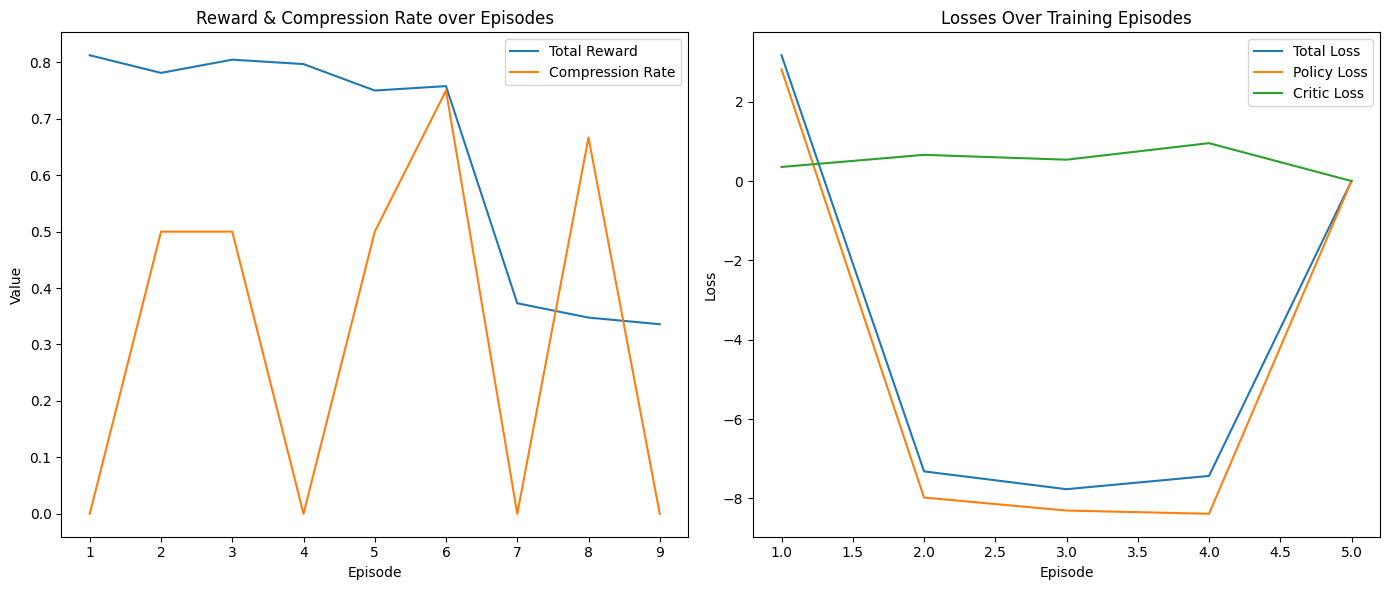

In [43]:
episodes = range(1, len(all_total_rewards) + 1)
print(len(episodes), len(all_total_losses), len(all_policy_losses), len(all_critic_losses))

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(episodes, all_total_rewards, label="Total Reward")
plt.plot(episodes, all_compression_rates, label="Compression Rate")
plt.xlabel("Episode")
plt.ylabel("Value")
plt.title("Reward & Compression Rate over Episodes")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(episodes[:len(all_total_losses)], all_total_losses, label="Total Loss")
plt.plot(episodes[:len(all_policy_losses)], all_policy_losses, label="Policy Loss")
plt.plot(episodes[:len(all_critic_losses)], all_critic_losses, label="Critic Loss")
plt.xlabel("Episode")
plt.ylabel("Loss")
plt.legend()
plt.title("Losses Over Training Episodes")

plt.tight_layout()
plt.show()
